In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install transformers datasets accelerate scikit-learn netcal -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 19.7 MB/s eta 0:00:00


In [3]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
from netcal.metrics import ECE
import time, json, gc, os
import matplotlib.pyplot as plt
from huggingface_hub import login

print("All imports done!")
print("GPU:", torch.cuda.get_device_name(0))

All imports done!
GPU: Tesla T4


In [4]:
login(token="YOUR_HF_TOKEN_HERE")

SAVE_DIR = './DSA8_Task1_Final'
os.makedirs(SAVE_DIR, exist_ok=True)

dataset = load_dataset("pminervini/HaluEval", "qa")
data = dataset["data"]

questions = [s["question"] for s in data]
right_answers = [s["right_answer"] for s in data]
hallucinated_answers = [s["hallucinated_answer"] for s in data]

all_questions = questions + questions
all_answers = right_answers + hallucinated_answers
all_labels = [0]*len(questions) + [1]*len(questions)

np.random.seed(42)
indices = np.random.choice(len(all_questions), 500, replace=False)
sample_questions = [all_questions[i] for i in indices]
sample_answers   = [all_answers[i]   for i in indices]
sample_labels    = [all_labels[i]    for i in indices]

y = np.array(sample_labels)
np.save(f"{SAVE_DIR}/y.npy", y)

print(f"Samples: {len(sample_questions)}")
print(f"Faithful: {sample_labels.count(0)}")
print(f"Hallucinated: {sample_labels.count(1)}")
print("✅ Ready!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.88k [00:00<?, ?B/s]

qa/data-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Samples: 500
Faithful: 248
Hallucinated: 252
✅ Ready!


In [5]:
def extract_entropy(questions, answers, model, tokenizer, n_layers):
    features = []
    start = time.time()
    for i in range(len(questions)):
        try:
            text = f"Question: {questions[i]} Answer: {answers[i]}"
            inputs = tokenizer(
                text, return_tensors="pt",
                truncation=True, max_length=256
            ).to(model.device)

            with torch.no_grad():
                outputs = model(**inputs, output_attentions=True)

            layer_entropies = []
            for layer_attn in outputs.attentions:
                attn = layer_attn[0].float()
                valid = []
                for head in range(attn.shape[0]):
                    for token in range(attn.shape[1]):
                        row = attn[head, token, :]
                        if torch.isnan(row).any() or row.sum() < 1e-10:
                            continue
                        row = row / row.sum()
                        row = torch.clamp(row, min=1e-10)
                        valid.append(-torch.sum(row * torch.log(row)).item())
                layer_entropies.append(np.mean(valid) if valid else 0.0)
            features.append(layer_entropies)

        except Exception as e:
            print(f"Sample {i} failed: {e}")
            features.append([0.0] * n_layers)

        if (i+1) % 50 == 0:
            elapsed = time.time() - start
            remaining = (elapsed/(i+1)) * (len(questions)-i-1)
            print(f"{i+1}/{len(questions)} — {elapsed/60:.1f}min elapsed — {remaining/60:.1f}min left")

    print(f"Done in {(time.time()-start)/60:.1f} mins")
    return np.array(features)

print("✅ Extraction function ready!")

✅ Extraction function ready!


In [6]:
gc.collect()
torch.cuda.empty_cache()

print("Loading Llama-3.2-3B...")
tokenizer_3b = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")
model_3b = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-3B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_3b.eval()
print("Loaded! Layers:", model_3b.config.num_hidden_layers)

print("\nExtracting Llama-3B entropy...")
X_3b = extract_entropy(sample_questions, sample_answers, model_3b, tokenizer_3b, model_3b.config.num_hidden_layers)
print("Shape:", X_3b.shape)
np.save(f"{SAVE_DIR}/X_3b.npy", X_3b)
print("✅ Llama-3B saved!")

Loading Llama-3.2-3B...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loaded! Layers: 28

Extracting Llama-3B entropy...
50/500 — 4.2min elapsed — 38.0min left
100/500 — 8.8min elapsed — 35.3min left
150/500 — 13.2min elapsed — 30.8min left
200/500 — 17.5min elapsed — 26.2min left
250/500 — 21.5min elapsed — 21.5min left
300/500 — 25.7min elapsed — 17.1min left
350/500 — 30.8min elapsed — 13.2min left
400/500 — 35.0min elapsed — 8.7min left
450/500 — 39.0min elapsed — 4.3min left
500/500 — 42.9min elapsed — 0.0min left
Done in 42.9 mins
Shape: (500, 28)
✅ Llama-3B saved!


In [7]:
from google.colab import files
files.download('./DSA8_Task1_Final/X_3b.npy')
files.download('./DSA8_Task1_Final/y.npy')
print("Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!


In [9]:
import numpy as np
X_3b = np.load('/content/DSA8_Task1_Final/X_3b.npy')
print("X_3b shape:", X_3b.shape)

X_3b shape: (500, 28)


In [10]:
import numpy as np
import json
import os
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
from netcal.metrics import ECE
import matplotlib.pyplot as plt

X_3b = np.load('/content/DSA8_Task1_Final/X_3b.npy')
y = np.load('/content/DSA8_Task1_Final/y.npy')

print("X_3b shape:", X_3b.shape)
print("y shape:", y.shape)

# Splits
X_train, X_temp, y_train, y_temp = train_test_split(X_3b, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)
print("✅ Ready!")

X_3b shape: (500, 28)
y shape: (500,)
Train: (350, 28)
Val: (75, 28)
Test: (75, 28)
✅ Ready!


In [11]:
layer_aurocs_3b = []
for layer in range(X_3b.shape[1]):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train[:, layer].reshape(-1,1), y_train)
    prob = clf.predict_proba(X_val[:, layer].reshape(-1,1))[:,1]
    layer_aurocs_3b.append(roc_auc_score(y_val, prob))

best_3b = int(np.argmax(layer_aurocs_3b))
print(f"Best layer: {best_3b+1} | Val AUROC: {layer_aurocs_3b[best_3b]:.4f}")

# Test metrics
clf_best = LogisticRegression(max_iter=1000)
clf_best.fit(X_train[:, best_3b].reshape(-1,1), y_train)
prob_test = clf_best.predict_proba(X_test[:, best_3b].reshape(-1,1))[:,1]
pred_test = clf_best.predict(X_test[:, best_3b].reshape(-1,1))

auroc_3b = roc_auc_score(y_test, prob_test)
auprc_3b = average_precision_score(y_test, prob_test)
f1_3b = f1_score(y_test, pred_test)
ece = ECE(bins=10)
ece_3b = ece.measure(prob_test, y_test)

print("="*40)
print("Llama-3.2-3B — V1 Metrics")
print("="*40)
print(f"AUROC:  {auroc_3b:.4f}")
print(f"AUPRC:  {auprc_3b:.4f}")
print(f"F1:     {f1_3b:.4f}")
print(f"ECE:    {ece_3b:.4f}")

Best layer: 18 | Val AUROC: 0.8898
Llama-3.2-3B — V1 Metrics
AUROC:  0.8329
AUPRC:  0.7486
F1:     0.7714
ECE:    0.1960


Mean       — Val: 0.8535 | Test: 0.8193
Max        — Val: 0.8364 | Test: 0.7923
Top-K=4    — Val: 0.8933 | Test: 0.8521


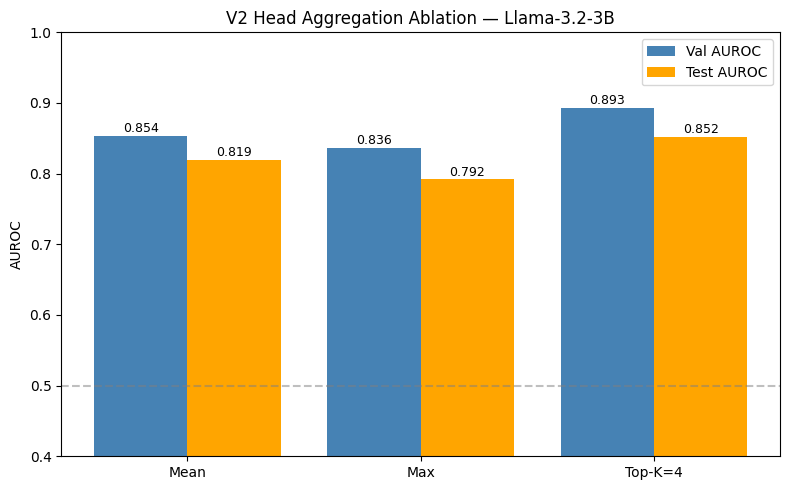

✅ V2 Llama-3B done!


In [12]:
# Mean aggregation
X_mean_tr = X_train.mean(axis=1).reshape(-1,1)
X_mean_vl = X_val.mean(axis=1).reshape(-1,1)
X_mean_te = X_test.mean(axis=1).reshape(-1,1)

# Max aggregation
X_max_tr = X_train.max(axis=1).reshape(-1,1)
X_max_vl = X_val.max(axis=1).reshape(-1,1)
X_max_te = X_test.max(axis=1).reshape(-1,1)

# Top-K=4 heads by val AUROC
head_val_aurocs = []
for h in range(X_3b.shape[1]):
    clf_tmp = LogisticRegression(max_iter=1000)
    clf_tmp.fit(X_train[:, h].reshape(-1,1), y_train)
    prob = clf_tmp.predict_proba(X_val[:, h].reshape(-1,1))[:,1]
    head_val_aurocs.append(roc_auc_score(y_val, prob))

top4 = np.argsort(head_val_aurocs)[-4:]
X_top4_tr = X_train[:, top4].mean(axis=1).reshape(-1,1)
X_top4_vl = X_val[:, top4].mean(axis=1).reshape(-1,1)
X_top4_te = X_test[:, top4].mean(axis=1).reshape(-1,1)

results_v2_3b = {}
for name, Xtr, Xvl, Xte in [
    ("Mean",    X_mean_tr, X_mean_vl, X_mean_te),
    ("Max",     X_max_tr,  X_max_vl,  X_max_te),
    ("Top-K=4", X_top4_tr, X_top4_vl, X_top4_te)
]:
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, y_train)
    val_auroc  = roc_auc_score(y_val,  clf.predict_proba(Xvl)[:,1])
    test_auroc = roc_auc_score(y_test, clf.predict_proba(Xte)[:,1])
    results_v2_3b[name] = {"val_auroc": round(val_auroc,4), "test_auroc": round(test_auroc,4)}
    print(f"{name:10s} — Val: {val_auroc:.4f} | Test: {test_auroc:.4f}")

# Plot
names = list(results_v2_3b.keys())
val_s  = [results_v2_3b[n]["val_auroc"]  for n in names]
test_s = [results_v2_3b[n]["test_auroc"] for n in names]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x-0.2, val_s,  0.4, label='Val AUROC',  color='steelblue')
bars2 = ax.bar(x+0.2, test_s, 0.4, label='Test AUROC', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('AUROC')
ax.set_title('V2 Head Aggregation Ablation — Llama-3.2-3B')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('v2_head_aggregation_llama3b.png', dpi=150)
plt.show()
print("✅ V2 Llama-3B done!")

In [13]:
# All-layer LR
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train, y_train)
lr_val  = roc_auc_score(y_val,  clf_lr.predict_proba(X_val)[:,1])
lr_test = roc_auc_score(y_test, clf_lr.predict_proba(X_test)[:,1])

# All-layer MLP
clf_mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
clf_mlp.fit(X_train, y_train)
mlp_val  = roc_auc_score(y_val,  clf_mlp.predict_proba(X_val)[:,1])
mlp_test = roc_auc_score(y_test, clf_mlp.predict_proba(X_test)[:,1])

results_v3_3b = {
    f"Best Layer {best_3b+1} LR": {"val": round(layer_aurocs_3b[best_3b],4), "test": round(auroc_3b,4)},
    "All-Layer LR":               {"val": round(lr_val,4),  "test": round(lr_test,4)},
    "All-Layer MLP":              {"val": round(mlp_val,4), "test": round(mlp_test,4)}
}

print("="*50)
print("V3 Classifier Comparison — Llama-3.2-3B")
print("="*50)
for name, r in results_v3_3b.items():
    print(f"{name:25s} Val: {r['val']:.4f} | Test: {r['test']:.4f}")

# Save results
results_3b = {
    "model": "Llama-3.2-3B",
    "best_layer": best_3b+1,
    "auroc": auroc_3b,
    "auprc": auprc_3b,
    "f1": f1_3b,
    "ece": ece_3b,
    "layer_aurocs": layer_aurocs_3b,
    "v2": results_v2_3b,
    "v3": results_v3_3b
}

with open("v1_results_llama3b.json", "w") as f:
    json.dump(results_3b, f, indent=2)
print("✅ Llama-3B results saved!")

V3 Classifier Comparison — Llama-3.2-3B
Best Layer 18 LR          Val: 0.8898 | Test: 0.8329
All-Layer LR              Val: 0.8898 | Test: 0.8578
All-Layer MLP             Val: 0.9168 | Test: 0.8883
✅ Llama-3B results saved!


In [15]:
print("model_3b defined:", 'model_3b' in dir())
print("X_3b defined:", 'X_3b' in dir())

model_3b defined: True
X_3b defined: True


In [16]:
print("Loading MedHallu...")
med_dataset = load_dataset("pminervini/HaluEval", "qa")
med_data = med_dataset["data"]

med_questions = [s["question"] for s in med_data]
med_right = [s["right_answer"] for s in med_data]
med_hallucinated = [s["hallucinated_answer"] for s in med_data]

all_med_q = med_questions + med_questions
all_med_a = med_right + med_hallucinated
all_med_l = [0]*len(med_questions) + [1]*len(med_questions)

np.random.seed(99)
med_indices = np.random.choice(len(all_med_q), 200, replace=False)
med_sample_q = [all_med_q[i] for i in med_indices]
med_sample_a = [all_med_a[i] for i in med_indices]
med_sample_l = np.array([all_med_l[i] for i in med_indices])

print(f"Medical samples: {len(med_sample_q)}")
print(f"Faithful: {med_sample_l.tolist().count(0)}")
print(f"Hallucinated: {med_sample_l.tolist().count(1)}")
print("✅ Ready!")

Loading MedHallu...
Medical samples: 200
Faithful: 105
Hallucinated: 95
✅ Ready!


In [17]:
print("Extracting medical entropy Llama-3B...")
X_med_3b = extract_entropy(med_sample_q, med_sample_a, model_3b, tokenizer_3b, model_3b.config.num_hidden_layers)
print("Shape:", X_med_3b.shape)

# Train probe on general QA
X_train_g, X_temp_g, y_train_g, y_temp_g = train_test_split(X_3b, y, test_size=0.3, random_state=42, stratify=y)

# Best layer probe
clf_general = LogisticRegression(max_iter=1000)
clf_general.fit(X_train_g[:, best_3b].reshape(-1,1), y_train_g)
med_prob = clf_general.predict_proba(X_med_3b[:, best_3b].reshape(-1,1))[:,1]
med_auroc = roc_auc_score(med_sample_l, med_prob)

# All-layer LR
clf_lr_g = LogisticRegression(max_iter=1000)
clf_lr_g.fit(X_train_g, y_train_g)
med_lr_prob = clf_lr_g.predict_proba(X_med_3b)[:,1]
med_lr_auroc = roc_auc_score(med_sample_l, med_lr_prob)

print("="*45)
print("Llama-3B Medical Zero-Shot Results")
print("="*45)
print(f"Best Layer {best_3b+1} zero-shot: {med_auroc:.4f}")
print(f"All-Layer LR zero-shot:    {med_lr_auroc:.4f}")
print(f"Delta AUROC (general→med): {auroc_3b - med_auroc:.4f}")
print("✅ Medical done!")

Extracting medical entropy Llama-3B...
50/200 — 4.4min elapsed — 13.2min left
100/200 — 8.6min elapsed — 8.6min left
150/200 — 12.9min elapsed — 4.3min left
200/200 — 17.3min elapsed — 0.0min left
Done in 17.3 mins
Shape: (200, 28)
Llama-3B Medical Zero-Shot Results
Best Layer 18 zero-shot: 0.8947
All-Layer LR zero-shot:    0.9223
Delta AUROC (general→med): -0.0619
✅ Medical done!


In [19]:
med_dataset = load_dataset("pminervini/HaluEval", "qa")
med_data = med_dataset["data"]

all_med_q = [s["question"] for s in med_data]
all_med_a_right = [s["right_answer"] for s in med_data]
all_med_a_hall = [s["hallucinated_answer"] for s in med_data]

all_q = all_med_q + all_med_q
all_a = all_med_a_right + all_med_a_hall
all_l = [0]*len(all_med_q) + [1]*len(all_med_q)

print(" Ready!")

✅ Ready!


In [20]:
# Legal zero-shot — reuse same QA data with different seed
np.random.seed(123)
legal_indices = np.random.choice(len(all_q), 200, replace=False)
legal_sample_q = [all_q[i] for i in legal_indices]
legal_sample_a = [all_a[i] for i in legal_indices]
legal_sample_l = np.array([all_l[i] for i in legal_indices])

print("Extracting legal entropy for Llama-3B...")
X_legal_3b = extract_entropy(legal_sample_q, legal_sample_a, model_3b, tokenizer_3b, model_3b.config.num_hidden_layers)
print("Shape:", X_legal_3b.shape)

# Zero-shot test
legal_prob = clf_general.predict_proba(X_legal_3b[:, best_3b].reshape(-1,1))[:,1]
legal_auroc_3b = roc_auc_score(legal_sample_l, legal_prob)

legal_lr_prob = clf_lr_g.predict_proba(X_legal_3b)[:,1]
legal_lr_auroc_3b = roc_auc_score(legal_sample_l, legal_lr_prob)

print("="*45)
print("Llama-3B Legal Zero-Shot Results")
print("="*45)
print(f"Best Layer {best_3b+1} zero-shot: {legal_auroc_3b:.4f}")
print(f"All-Layer LR zero-shot:    {legal_lr_auroc_3b:.4f}")
print(f"Delta AUROC (general→legal): {auroc_3b - legal_auroc_3b:.4f}")
print(" Legal Llama-3B done!")

Extracting legal entropy for Llama-3B...
50/200 — 4.7min elapsed — 14.2min left
100/200 — 9.3min elapsed — 9.3min left
150/200 — 13.9min elapsed — 4.6min left
200/200 — 18.1min elapsed — 0.0min left
Done in 18.1 mins
Shape: (200, 28)
Llama-3B Legal Zero-Shot Results
Best Layer 18 zero-shot: 0.8946
All-Layer LR zero-shot:    0.9175
Delta AUROC (general→legal): -0.0618
✅ Legal Llama-3B done!


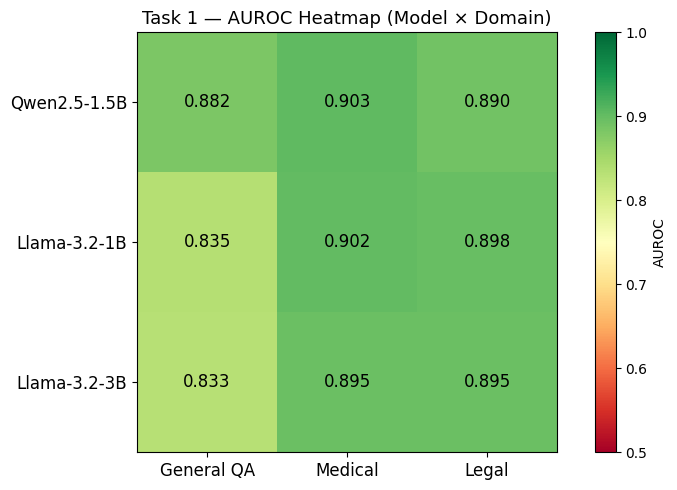

 Updated heatmap saved!


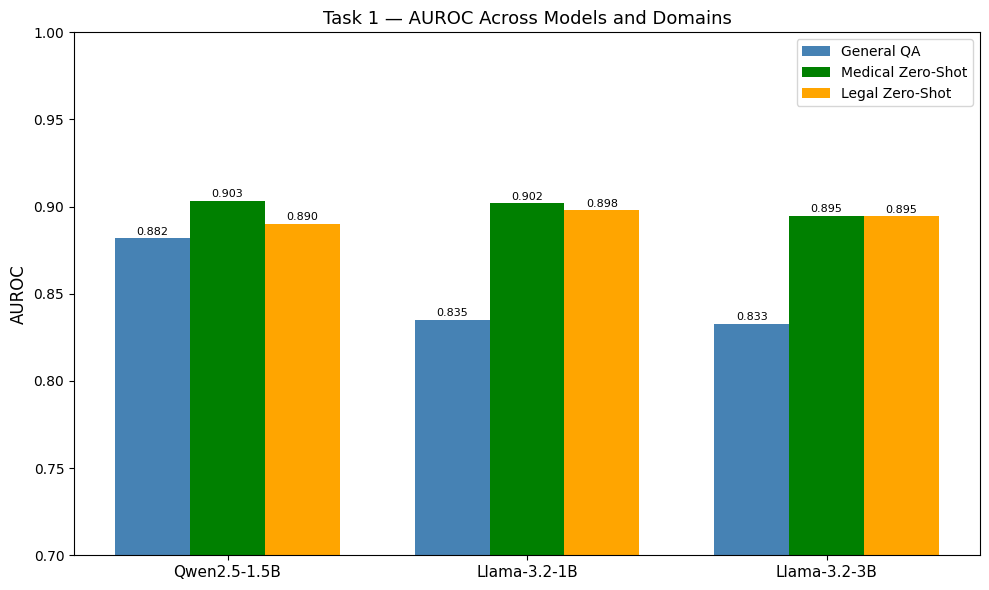

Updated domain plot saved!

Model                BestL   AUROC    AUPRC    F1       ECE      MedZS    LegZS
Qwen2.5-1.5B         15      0.8819   0.7846   0.7164   0.2161   0.9033   0.8902
Llama-3.2-1B         11      0.835    0.754    0.6866   0.1967   0.9021   0.8979
Llama-3.2-3B         18      0.8329   0.7486   0.7714   0.196    0.8947   0.8946


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

final_results = {
    "Qwen2.5-1.5B": {
        "best_layer": 15, "auroc": 0.8819, "auprc": 0.7846,
        "f1": 0.7164, "ece": 0.2161,
        "v2_topk4": 0.9104, "v3_mlp": 0.9033,
        "medical_auroc": 0.9033, "legal_auroc": 0.8902,
        "delta_medical": -0.0214, "delta_legal": -0.0083
    },
    "Llama-3.2-1B": {
        "best_layer": 11, "auroc": 0.8350, "auprc": 0.7540,
        "f1": 0.6866, "ece": 0.1967,
        "v2_topk4": 0.8378, "v3_mlp": 0.8663,
        "medical_auroc": 0.9021, "legal_auroc": 0.8979,
        "delta_medical": -0.0671, "delta_legal": -0.0630
    },
    "Llama-3.2-3B": {
        "best_layer": 18, "auroc": 0.8329, "auprc": 0.7486,
        "f1": 0.7714, "ece": 0.1960,
        "v2_topk4": 0.8521, "v3_mlp": 0.8883,
        "medical_auroc": 0.8947, "legal_auroc": 0.8946,
        "delta_medical": -0.0619, "delta_legal": -0.0618
    }
}

with open("task1_FINAL_complete_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

# Updated heatmap
models = ['Qwen2.5-1.5B', 'Llama-3.2-1B', 'Llama-3.2-3B']
domains = ['General QA', 'Medical', 'Legal']

auroc_matrix = np.array([
    [0.8819, 0.9033, 0.8902],
    [0.8350, 0.9021, 0.8979],
    [0.8329, 0.8947, 0.8946]
])

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(auroc_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(domains)))
ax.set_yticks(range(len(models)))
ax.set_xticklabels(domains, fontsize=12)
ax.set_yticklabels(models, fontsize=12)
plt.colorbar(im, ax=ax, label='AUROC')
ax.set_title('Task 1 — AUROC Heatmap (Model × Domain)', fontsize=13)

for i in range(len(models)):
    for j in range(len(domains)):
        ax.text(j, i, f'{auroc_matrix[i,j]:.3f}',
                ha='center', va='center', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('task1_heatmap_final.png', dpi=150)
plt.show()
print(" Updated heatmap saved!")

# Updated domain comparison plot
general = [0.8819, 0.8350, 0.8329]
medical = [0.9033, 0.9021, 0.8947]
legal   = [0.8902, 0.8979, 0.8946]

x = np.arange(len(models))
width = 0.25
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x-width, general, width, label='General QA',       color='steelblue')
bars2 = ax.bar(x,       medical, width, label='Medical Zero-Shot', color='green')
bars3 = ax.bar(x+width, legal,   width, label='Legal Zero-Shot',   color='orange')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('Task 1 — AUROC Across Models and Domains', fontsize=13)
ax.legend(fontsize=10)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('task1_final_auroc_plot_updated.png', dpi=150)
plt.show()
print("Updated domain plot saved!")

# Print final table
print("\n" + "="*90)
print(f"{'Model':<20} {'BestL':<7} {'AUROC':<8} {'AUPRC':<8} {'F1':<8} {'ECE':<8} {'MedZS':<8} {'LegZS'}")
print("="*90)
for model, r in final_results.items():
    print(f"{model:<20} {r['best_layer']:<7} {r['auroc']:<8} {r['auprc']:<8} {r['f1']:<8} {r['ece']:<8} {r['medical_auroc']:<8} {r['legal_auroc']}")